In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [3]:
dataset=pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv",header=1,parse_dates=[0],index_col=0,dayfirst=True)

C:\Users\Adit Sharma\AppData\Local\Temp\ipykernel_11536\3371622800.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset=pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv",header=1,parse_dates=[0],index_col=0,dayfirst=True)


In [4]:
dataset.describe()

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,245,245,245,245,245,245,245,245,245,245,245,245,244
unique,5,2,20,63,19,40,174,167,199,107,175,128,9
top,07,2012,35,64,14,0,88.9,7.9,8,1.1,3,0.4,fire
freq,62,244,29,10,43,133,8,5,5,8,5,12,131


In [5]:
dataset

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
day,,,,,,,,,,,,,
01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire


In [6]:
dataset.head()

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
day,,,,,,,,,,,,,
01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 01 to 30
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   month        245 non-null    object
 1   year         245 non-null    object
 2   Temperature  245 non-null    object
 3    RH          245 non-null    object
 4    Ws          245 non-null    object
 5   Rain         245 non-null    object
 6   FFMC         245 non-null    object
 7   DMC          245 non-null    object
 8   DC           245 non-null    object
 9   ISI          245 non-null    object
 10  BUI          245 non-null    object
 11  FWI          245 non-null    object
 12  Classes      244 non-null    object
dtypes: object(13)
memory usage: 26.9+ KB


Data Cleaning

In [8]:
dataset.isnull().sum()

month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [9]:
dataset.isnull().any(axis=1)

day
01    False
02    False
03    False
04    False
05    False
      ...  
26    False
27    False
28    False
29    False
30    False
Length: 246, dtype: bool

In [10]:
dataset[dataset.isnull().any(axis=1)]

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
day,,,,,,,,,,,,,
Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [11]:
dataset.loc[dataset.index[:122], "Region"] = 0
dataset.loc[dataset.index[122:], "Region"] = 1
df=dataset




In [12]:
#removing null values
df=df.dropna().reset_index(drop=True)
df

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1.0
1,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,1.0
2,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1.0
3,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,1.0
4,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1.0
240,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1.0
241,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1.0
242,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1.0


In [13]:
df.iloc[[122]]

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1.0


In [14]:
df=df.drop(122).reset_index(drop=True)

In [15]:
df.iloc[[122]]

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1.0


In [16]:
df.columns

Index(['month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC',
       'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [17]:
##fix spaces in columns names
df.columns=df.columns.str.strip()

In [18]:
df.columns

Index(['month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC',
       'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   month        243 non-null    object 
 1   year         243 non-null    object 
 2   Temperature  243 non-null    object 
 3   RH           243 non-null    object 
 4   Ws           243 non-null    object 
 5   Rain         243 non-null    object 
 6   FFMC         243 non-null    object 
 7   DMC          243 non-null    object 
 8   DC           243 non-null    object 
 9   ISI          243 non-null    object 
 10  BUI          243 non-null    object 
 11  FWI          243 non-null    object 
 12  Classes      243 non-null    object 
 13  Region       243 non-null    float64
dtypes: float64(1), object(13)
memory usage: 26.7+ KB


In [20]:
df.head(
)

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1.0
1,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,1.0
2,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1.0
3,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,1.0
4,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,1.0


In [21]:
#change the required colums as int dta type-month,year,temp,rh,ws
df[["month","year","Temperature","RH","Ws"]]=df[["month","year","Temperature","RH","Ws"]].astype(int)

In [22]:
df.head()

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1.0
1,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,1.0
2,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1.0
3,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,1.0
4,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,1.0


In [23]:
df.isnull().sum()

month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

Changing other columns to float datatype


In [24]:
objects=[features for features in df.columns if df[features].dtype=="object"]

In [25]:
for i in objects:
    if i!="Classes":
        df[i]=df[i].astype("float")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   month        243 non-null    int64  
 1   year         243 non-null    int64  
 2   Temperature  243 non-null    int64  
 3   RH           243 non-null    int64  
 4   Ws           243 non-null    int64  
 5   Rain         243 non-null    float64
 6   FFMC         243 non-null    float64
 7   DMC          243 non-null    float64
 8   DC           243 non-null    float64
 9   ISI          243 non-null    float64
 10  BUI          243 non-null    float64
 11  FWI          243 non-null    float64
 12  Classes      243 non-null    object 
 13  Region       243 non-null    float64
dtypes: float64(8), int64(5), object(1)
memory usage: 26.7+ KB


In [27]:
objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [28]:
df.describe()

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.0
mean,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,1.0
std,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.0
min,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,1.0
25%,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,1.0
50%,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,1.0
75%,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.0
max,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.0


In [29]:
df.head()

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1.0
1,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,1.0
2,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1.0
3,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,1.0
4,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,1.0


In [30]:
df.to_csv("Algerian_forest_fires_dataset_UPDATE_cleaned.csv",index=False)

In [31]:
##Exploratory Data Analysis
#drop month and year
df_copy = df.drop(['month','year'],axis=1)

In [32]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,1.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,1.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,1.0


In [33]:
df_copy['Classes']=np.where(df_copy['Classes']=="not fire",0,1)

In [34]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1,1.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1,1.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,1.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1,1.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1,1.0


In [35]:
df_copy['Classes'].value_counts()

Classes
1    241
0      2
Name: count, dtype: int64

In [36]:
df_copy.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1.0
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,1,1.0
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,1,1.0
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,1,1.0
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,1,1.0


In [37]:
df_copy['Classes'].value_counts()

Classes
1    241
0      2
Name: count, dtype: int64

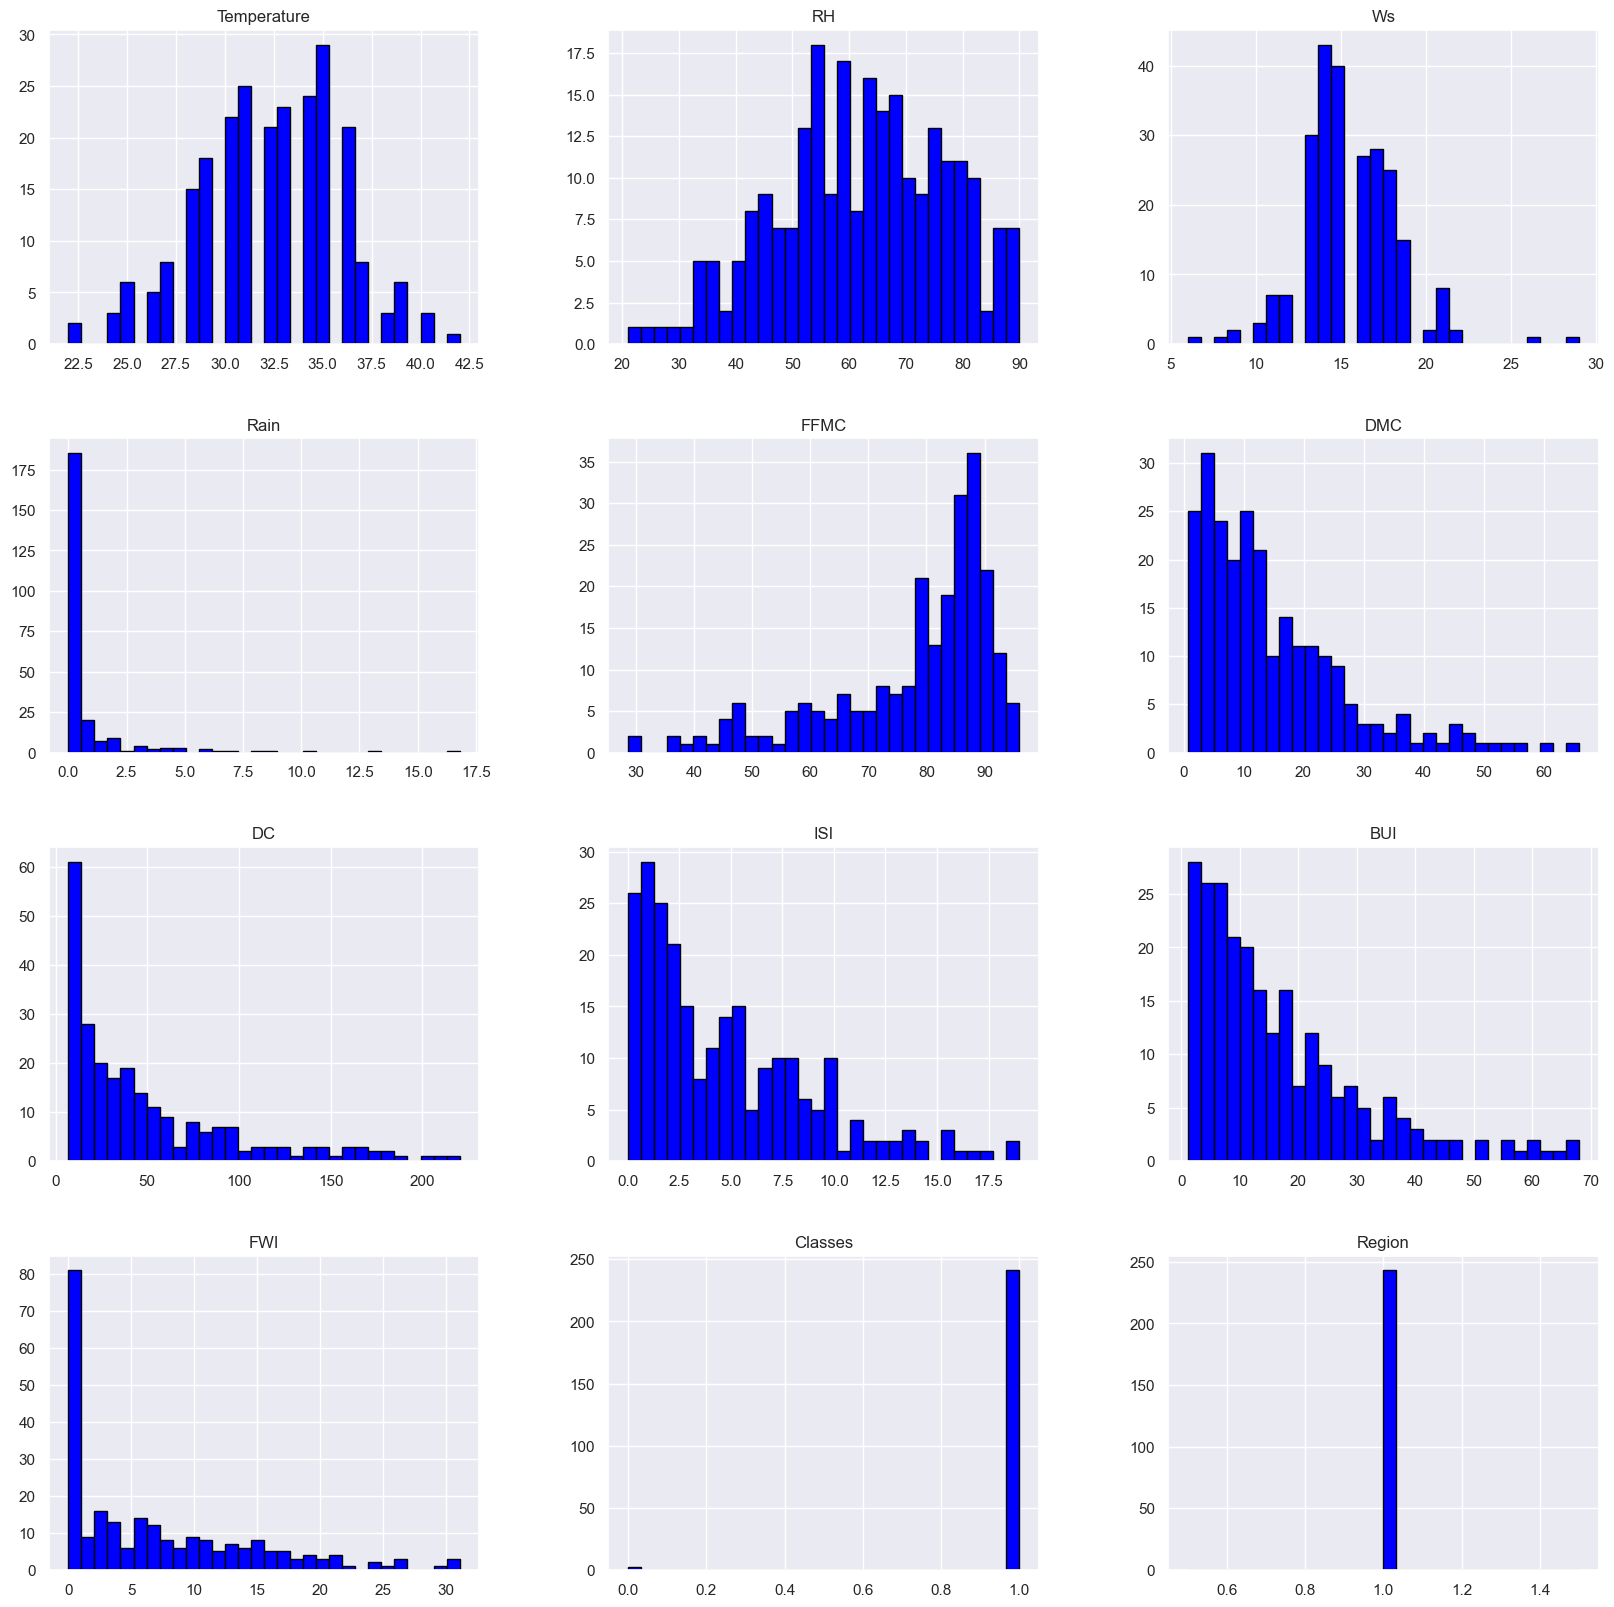

In [38]:
##Plot desnity plot for features
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()  # activates seaborn styling
df_copy.hist(figsize=(20,20), color='blue', edgecolor='black', bins=30)
plt.show()


<Axes: ylabel='count'>

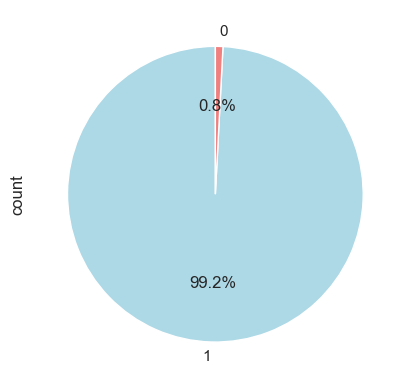

In [39]:
##Percentage for Pie Chart
df_copy['Classes'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])

In [47]:
##Correlation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.179959,NaN
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.129027,NaN
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.081375,NaN
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.578144,NaN
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.231193,NaN
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.073516,NaN
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.079632,NaN
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.097617,NaN
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.076928,NaN
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.084474,NaN


<Axes: >

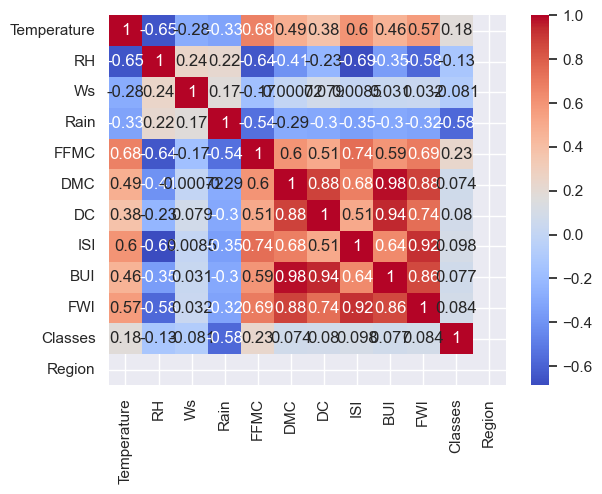

In [51]:
sns.heatmap(df_copy.corr(), annot=True, cmap='coolwarm')

<Axes: >

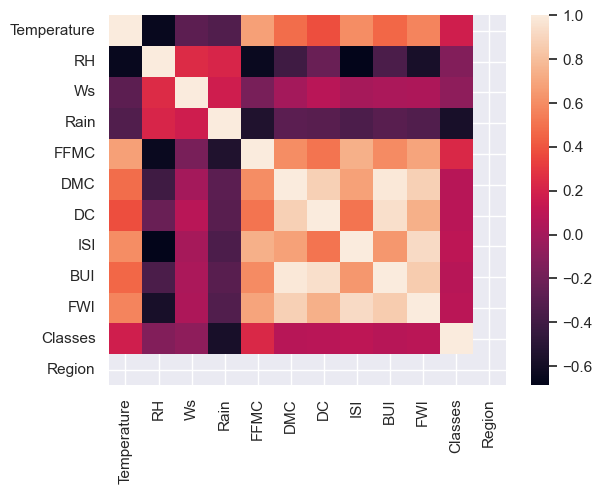

In [52]:
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

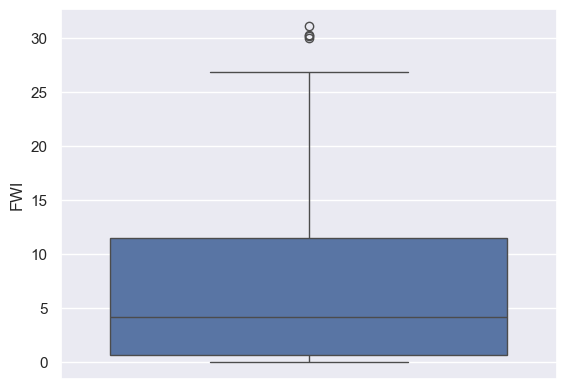

In [54]:
##Box Plots
sns.boxplot(df['FWI'])

In [55]:
df.head()

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1.0
1,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,1.0
2,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1.0
3,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,1.0
4,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,1.0


<Axes: xlabel='month', ylabel='count'>

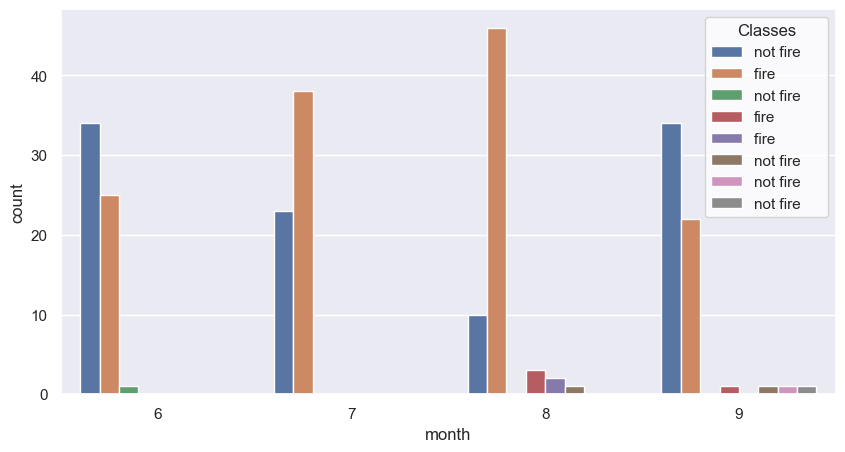

In [61]:
##Monthly Fire Analysis
dftemp=[df.loc[df['Region']==1]]
plt.subplots(figsize=(10,5))
sns.set_style("whitegrid")
sns.countplot(x='month',hue='Classes',data=df)